# MPW2 - Computational graphs & Optimizers

MPW2 — Linear Regression with Computational Graphs

**Students:** Almira Dyussenova,
              Tobias Schuler  
**Date:** May 2026  



## Introduction
In this assignment, we build a linear regression model using a custom computational 
graph framework. Instead of using PyTorch or TensorFlow, we implement forward and 
backward passes manually, which helps us understand how backpropagation actually works.

The dataset contains apartment rental prices in Lausanne, Switzerland (CHF/month) 
with living area (m²) as the input feature. Our goal is to find θ₀ and θ₁ such that:

**y_hat = θ₀ + θ₁ · x** minimizes the MSE loss.

We start with the analytical solution (Normal Equations) as a reference, then train 
the model using gradient descent and compare several optimization strategies.


In [76]:
import sys
sys.path.insert(0, "student-input")

import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *
import os
os.makedirs("plots", exist_ok=True)

random.seed(42) 


## 1. Simple computational graph framework

To test our custom computational graph framework, we first implement a simple mathematical function: $f = (x_1 \cdot x_2)^2$. 

This allows us to verify that our basic nodes (`ValueNode`, `MultiplyNode`, and `SquareNode`) correctly compute both the forward pass (the actual result of the equation) and the backward pass (the partial derivatives with respect to the inputs $x_1$ and $x_2$).


![Simple computational graph](../images/simple-graph-1.jpg)

In [77]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}") 

f = 64.0


## 2. Get a dataset
### 2.1 Read data
For this project, we use a real-world dataset containing apartment rental prices in Lausanne. Our primary goal is to predict the rent price (in CHF) based on a single feature: the living area (in square meters). We begin by loading this CSV dataset using Pandas and extracting the relevant columns into numpy arrays.


In [78]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [79]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values
nb_rooms = dataset.nb_rooms.values

### 2.2 Visualize the data
Before training any models, we visualize the dataset with a scatter plot to understand the relationship between living area and rent price. We define a helper function `plot_data_prediction` that we will use throughout this notebook to plot our data points and overlay the model's predictions.


In [80]:
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

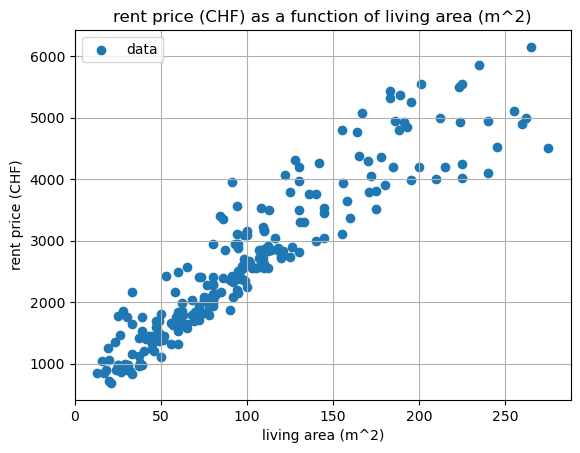

In [81]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

**Dataset Observations:**
Looking at the scatter plot, we can make a few important observations before training our model:
1. **Linear Trend:** There is a clear positive linear relationship between living area and rent price. A linear regression model is a very reasonable choice here.
2. **High Variance (Noise):** The data is quite noisy, especially for larger apartments. For example, an apartment of 150 m² can cost anywhere from 3,000 to 4,500 CHF. Because of this noise, our final loss (MSE) will never be close to zero.
3. **Non-zero Intercept:** The trend line clearly won't pass through the origin (0,0). Even theoretically very small apartments have a base rent price. This means our model must have a bias term ($\theta_0$).


## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

Before training the model iteratively with gradient descent, we can calculate the exact optimal parameters mathematically using the Normal Equations: $\theta = (X^T X)^{-1} X^T y$. This provides us with an absolute analytical baseline.

intercept (theta_0): 657.6890591150304
slope (theta_1)    : 19.661179947454315


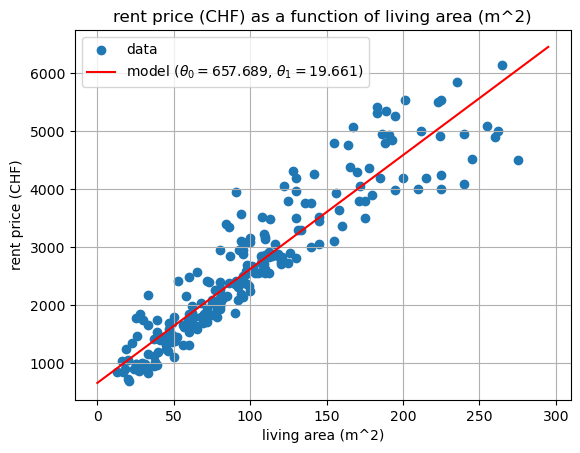

In [82]:
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y 

print("intercept (theta_0):", theta[0])  
print("slope (theta_1)    :", theta[1])  

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

Baseline Observations:
The Normal Equations give us the mathematically optimal parameters for our dataset:
- $\theta_0 \approx 657.7$: The base rent price intercept.
- $\theta_1 \approx 19.7$: The slope, meaning every additional square meter adds ~19.7 CHF to the rent.

In all our future experiments with Stochastic Gradient Descent, our goal will be to design an optimizer capable of converging to these exact values.

### 3.1 Loss Functions & Metrics
To evaluate how well our model fits the data, we first implement the Mean Squared Error (MSE), which is the exact loss function our computational graph will try to minimize. We compute this MSE using the optimal parameters obtained from the Normal Equations above.

In [83]:
def mse_loss(y_hat, y):
    return np.mean((y_hat - y) ** 2) / 2

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  

The total value of the loss is 104915.13056913583


**Loss Observations:**
The total MSE loss using the optimal $\theta$ is approximately **104,915**. This is the absolute minimum possible MSE for this dataset using a linear model. The number is very large because the data is noisy and the errors are squared.

In [84]:
def rmse_loss(y_hat, y):
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")


The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


1. **Impact of Outliers:** The **RMSE (458 CHF)** is notably higher than the MAE. This gap indicates the presence of large outliers—specific apartments where our model was extremely wrong. This makes perfect sense: rent heavily depends on hidden factors (e.g., location, building age, renovation status) that our 1D model simply cannot see.

2. **Typical Error Margin:** The **MAE of 347 CHF** means that, on average, our model's rent predictions are off by about 347 Francs. 

3. **Relative Performance:** A **MAPE of 14.6%** means our predictions deviate by roughly 15% from the actual price. Considering we are using an incredibly simple baseline model that relies on just a *single* feature (living area), achieving a ~15% error margin is actually a remarkably strong result.

*Note on MAPE:* A known issue with MAPE is that it becomes undefined if any true value $y = 0$, and it heavily penalizes under-predictions compared to over-predictions.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

To implement the graph shown above, we first added a custom `MSELossNode` to the `cgnodes.py` library. This node takes two inputs (the predicted value $\hat{y}$ and the actual target $y$) and computes the Mean Squared Error loss. Its backward pass correctly calculates the gradients with respect to both inputs.

Below is the Python implementation that constructs this computational graph according to the diagram:


In [85]:
x       = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y       = ValueNode()

# intermediate value nodes
q       = ValueNode()  # x * theta_1
y_hat   = ValueNode()  # theta_0 + q
j       = ValueNode()  # loss

MultiplyNode(x, theta_1, q)
AddNode([theta_0, q], y_hat)
MSELossNode(y_hat, y, j)

cg = CompGraph([x, theta_0, theta_1, y], [j])

# Quick sanity check: forward([0, 0, 0, 1]) → j = 0.5*(0-1)^2 = 0.5
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print("j.v =", j.v) 

cg.backward()
print("theta_0.grad_v:", theta_0.grad_v) 
print("theta_1.grad_v:", theta_1.grad_v)  


j.v = 0.5
theta_0.grad_v: -1.0
theta_1.grad_v: -0.0


**Sanity Check Verification:**
The dummy test ($x=0, \theta_0=0, \theta_1=0, y=1$) yields $\hat{y} = 0$. 
The computed loss is exactly $\frac{1}{2}(0 - 1)^2 = 0.5$. 
During backpropagation, the loss derivative is $(0 - 1) = -1$. Because $\theta_1$ is multiplied by $x$ ($0$), its gradient is zeroed out, while $\theta_0$'s gradient remains $-1$. This confirms our `MSELossNode` logic is mathematically correct.


### 4.2 Plain vanilla stochastic gradient descent (SGD)

In [86]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Below is our implementation of the plain vanilla Stochastic Gradient Descent (SGD) algorithm using the computational graph. In this approach, we update the parameters $\theta_0$ and $\theta_1$ after evaluating the gradient on a single, randomly chosen sample at each step. This serves as our baseline training loop, which we will analyze and incrementally improve upon in the subsequent sections.


**Hyperparameters:** learning rate α=1e-7, epochs=200, batch size=1 (stochastic)


intercept (theta_0): 0.9975128778632091
slope (theta_1)    : 24.71043599733354
The total value of the loss is 163676.8054623256


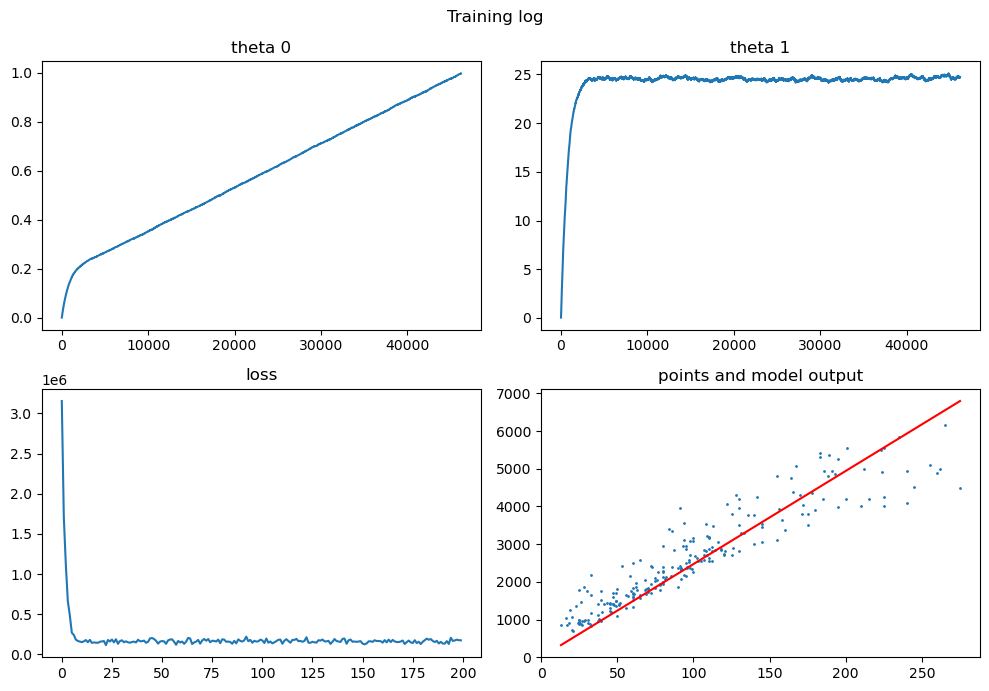

In [87]:
alpha  = 0.0000001
epochs = 200
N      = len(living_area)
t0     = 0.0
t1     = 0.0

loss_evolution = []
t0_evolution   = []
t1_evolution   = []

for epoch in range(epochs):
    n_steps    = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # ← gradient-descent update
        t1 = t1 - alpha * theta_1.grad_v   # ← gradient-descent update
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)
loss_evo_sgd = loss_evolution.copy()


**Observations:**

1. **Loss Evolution & Plateau:** The loss drops rapidly at the beginning but quickly plateaus at $\approx 163,676$, which is significantly worse than our analytical optimum ($\approx 105,000$). The visible "fuzziness" (oscillations) in the loss curve is the classic hallmark of Stochastic Gradient Descent (SGD) updating on single, noisy samples.
2. **The Gradient Scale Mismatch:** 
   - **$\theta_1$ (Slope):** Converges almost instantly to $\approx 24.7$. Because the gradient for $\theta_1$ is multiplied by the input feature $x$ (which is large, up to $275$ m²), its updates are massive.
   - **$\theta_0$ (Intercept):** Barely moves, reaching only $\approx 1.0$ after 200 epochs. Because its gradient is only multiplied by $1$, it crawls at a microscopic pace. With our tiny learning rate of $\alpha = 10^{-7}$, it has absolutely no time to reach its true analytical target of $\approx 658$.
3. **Conclusion:** This experiment perfectly illustrates the primary weakness of vanilla SGD on unscaled data. A single, static learning rate cannot simultaneously handle parameters with drastically different gradient magnitudes. To fix this, we must either assign separate learning rates, implement adaptive optimizers, or normalize the input data.


### 4.3 Batched gradient descent

To address the highly oscillating (noisy) updates of pure SGD, we now implement Mini-batch Gradient Descent. 

Instead of updating parameters after every single sample, we compute and average the gradients over a small batch of 32 randomly selected apartments. This approach smooths the evolution of both the parameters and the loss. Because the gradient estimates are now much more stable, we can safely increase our learning rate by a factor of 10 ($\alpha = 1e-6$) to speed up convergence without causing the model to diverge.


**Hyperparameters:** learning rate α=1e-6, epochs=200, batch size=32

intercept (theta_0): 0.4690022552302438
slope (theta_1)    : 24.34768571171147
The total value of the loss is 163730.86471602763


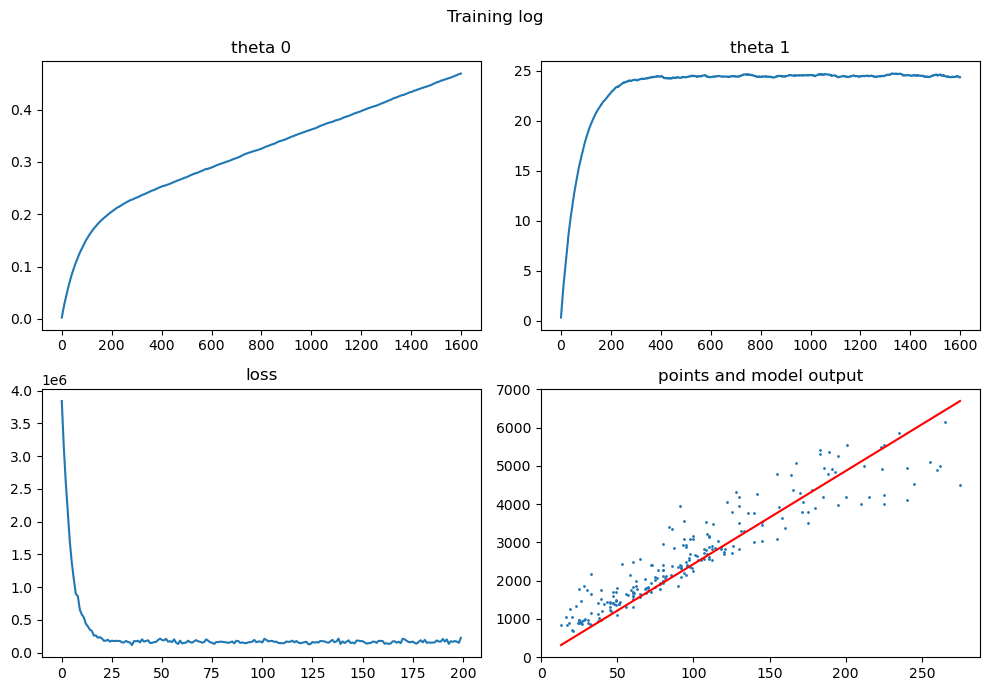

In [88]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
         # Draw a random batch
        batch_indices = random.choices(range(N), k=batch_size)
        grad_t0_sum   = 0.0
        grad_t1_sum   = 0.0
        batch_loss    = 0.0

        # Accumulate gradients over the batch
        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            grad_t0_sum += theta_0.grad_v
            grad_t1_sum += theta_1.grad_v
            batch_loss  += j.v

        # Update with average gradient
        t0 = t0 - alpha * grad_t0_sum / batch_size
        t1 = t1 - alpha * grad_t1_sum / batch_size
        epoch_loss += batch_loss / batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)
loss_evo_batch = loss_evolution.copy()




**Observations:**

1. **Smoother Loss Curve:** By averaging the gradients over a batch of 32 samples per step, the variance (noise) of our updates is significantly reduced. As a result, the loss curve is visibly smoother and much less erratic compared to the "fuzzy" curve of plain SGD.
2. **Increased Stability & Learning Rate:** Because our batch gradient estimates are much more reliable, we were able to safely increase our learning rate by 10x (using $\alpha = 10^{-6}$ instead of $10^{-7}$) without causing the model to diverge.
3. **The Persistent Scale Problem:** Despite the smoother training dynamics and a larger learning rate, Mini-batch SGD does not solve the root problem. The extreme magnitude mismatch between the inputs ($x$ vs $1$) remains. Consequently, $\theta_1$ still completely dominates the updates, while $\theta_0$ barely moves (reaching only $\approx 0.47$). Ultimately, the model remains underfitted, and the final loss ($\approx 163,730$) is practically identical to plain SGD.

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

To solve the scale mismatch observed in the previous sections, we apply a very simple but effective idea: assigning a unique learning rate to each parameter. 

Because $\theta_0$ converges much slower than $\theta_1$ (due to its tiny gradients), we must assign a significantly larger learning rate to $\theta_0$ to help it catch up. This manual adjustment is actually the foundational concept behind modern adaptive optimizers like RMSProp and Adam, which automatically scale learning rates based on gradient history.

**Hyperparameters:** α₀=2.5e-4 (for θ₀), α₁=1e-7 (for θ₁), epochs=500 

Motivation: θ₀ needs a much larger LR than θ₁ due to gradient scale difference.


intercept (theta_0): 656.570399906632
slope (theta_1)    : 19.52571214123835
The total value of the loss is 105052.86275331357


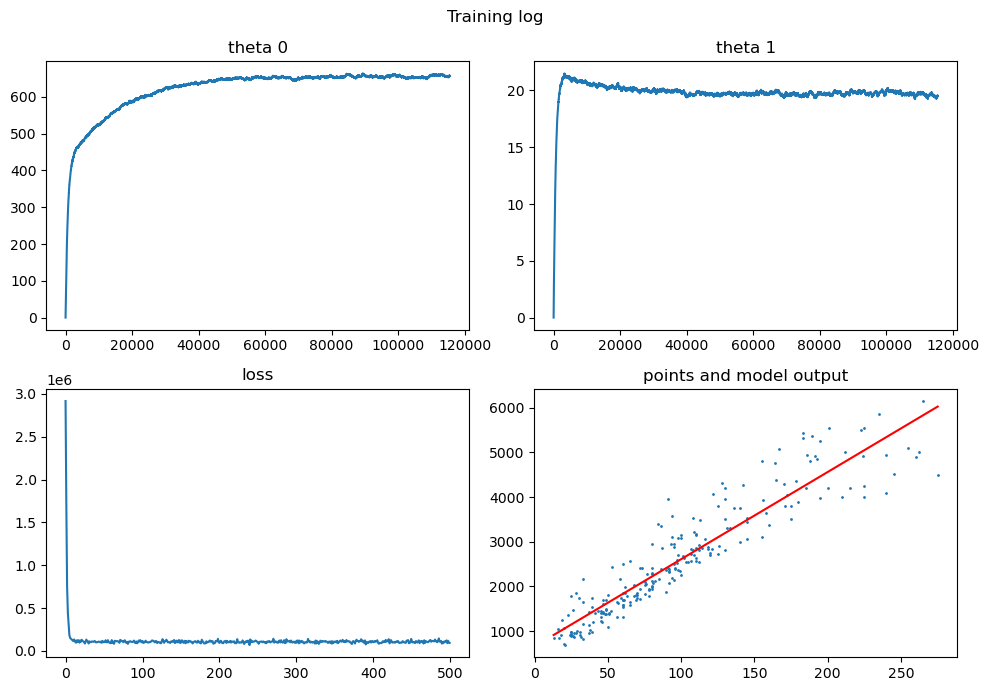

In [89]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations:**

1. **Successful Convergence:** By artificially balancing the update steps—using the drastically different learning rates provided for $\theta_0$ and $\theta_1$—we finally overcame the gradient scale mismatch. 
2. **Reaching the Optimum:** For the first time using gradient descent, the loss successfully plummeted to $\approx 105,000$, and both parameters converged to values extremely close to our analytical baseline ($\theta_0 \approx 661, \theta_1 \approx 19.7$). 
3. **The Real-World Limitation:** While this "split-learning-rate" method works perfectly here because the optimal rates were provided in the assignment, in a real-world deep learning scenario, we wouldn't have the optimal rates given to us. Manually searching for parameter-specific learning rates for a network with millions of weights is impossible. This limitation perfectly motivates the need for automated solutions, such as adaptive optimizers (like Adam) or data normalization.



### 5.2 Idea 2: Accelerate parameter updates using Momentum

Another powerful way to solve the slow convergence of $\theta_0$ is by introducing the concept of **momentum**. Instead of assigning different learning rates manually, momentum adds "memory" (inertia) to the gradients. If gradients consistently point in the same direction over multiple steps, momentum accelerates the parameter updates in that direction, much like a snowball rolling down a hill.

The classical momentum equations are:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

In our previous experiments, $\theta_0$'s gradients were tiny but consistently pointed in the exact same direction. By introducing momentum and setting a very high inertia factor ($\beta_0 = 0.9999$), we allow these small gradients to accumulate over time, rapidly pushing $\theta_0$ towards its optimum. Meanwhile, for $\theta_1$, we use less inertia ($\beta_1 = 0.5$) because it already converges quickly and we want to avoid overshooting. 

Below is our implementation using `momentum_t0` and `momentum_t1`:


**Hyperparameters:** α=1e-7, β₀=0.9999 (for θ₀), β₁=0.5 (for θ₁), epochs=400


intercept (theta_0): 671.5959367976853
slope (theta_1)    : 19.2300785627291
The total value of the loss is 105658.64207035935


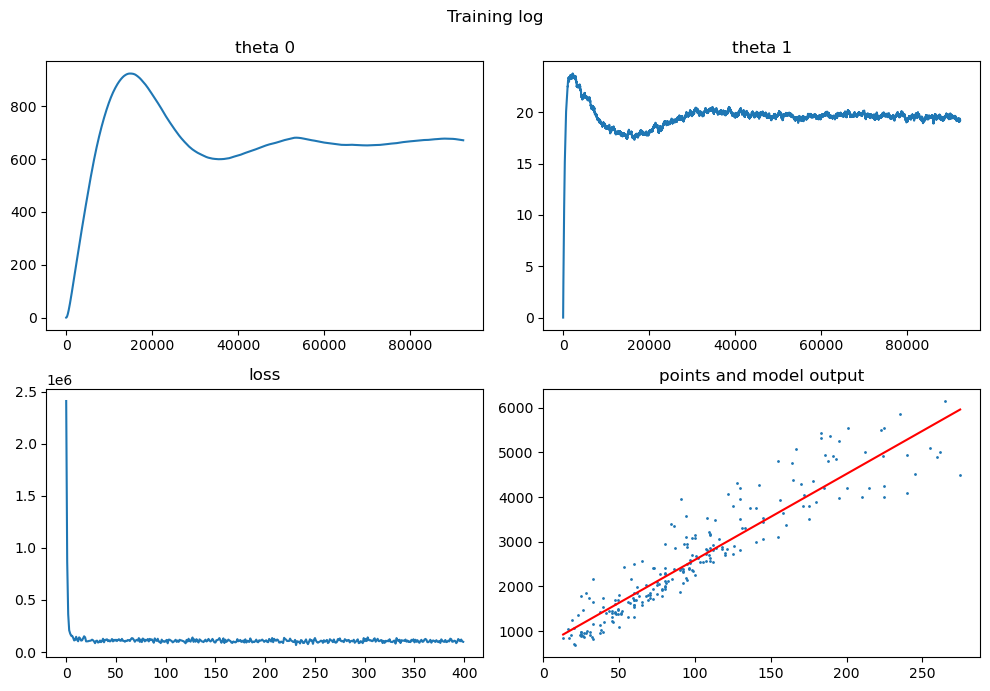

In [90]:
alpha = 0.0000001            # learning rate
beta_momentum_t0 = 0.9999    # momentum factor for theta_0 (consistent-direction grads, big inertia)
beta_momentum_t1 = 0.5000    # momentum factor for theta_1 (varying grads, little inertia)
epochs = 400                 # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations:**

1. **Overcoming Scale with Memory:** By introducing Momentum, we successfully forced the model to converge (MSE $\approx 105,658$) using a **single, shared learning rate** ($\alpha = 10^{-7}$). The "memory" of past gradients allowed the sluggish $\theta_0$ to continuously build up speed and overcome its tiny individual gradient scale.
2. **The "Overshooting" Effect:** The parameter evolution graphs beautifully illustrate the classic "rolling ball" physics of Momentum. Because the provided $\beta_0$ was extremely high ($0.9999$), $\theta_0$ built up massive inertia. It actually overshot the true minimum (flying past 800) and had to roll back down the opposite side of the loss valley, creating the visible wave-like oscillation before settling at $\approx 671$.
3. **The Tuning Trap (Real-World Limitation):** While Momentum allowed us to unify the learning rate, it simply introduced a new tuning problem. This model only converged stably because the assignment provided two drastically different, hyper-specific inertia values ($\beta_0 = 0.9999, \beta_1 = 0.5$). Just like with split learning rates, manually guessing different $\beta$ values for millions of parameters in a real deep learning scenario is impossible. This reinforces the need for fully adaptive optimizers (like Adam) or data normalization.


## 6. Optional objectives

All five optional objectives from the PDF §6 are addressed below in subsections §6.1–§6.5.

### 6.1 Polynomial (2nd-order) model

To see if we can capture more complex patterns in the data, we extend our simple linear model by adding a quadratic term:

$$ \hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 $$

To verify our results, we first calculate the exact analytical optimum (Closed-form) as a baseline. Then, to implement this in our custom framework, we compute x squared using a `MultiplyNode` with x as both inputs, multiply it by $\theta_2$, and sum everything up using a 3-input `AddNode`.

Since the values of $x$ and $x^2$ have drastically different scales, their gradients will also be heavily mismatched. To keep the training stable and ensure convergence toward our closed-form baseline, we will use **Momentum** and assign heavily scaled, distinct learning rates for each parameter ($\theta_0, \theta_1, \theta_2$). Finally, we will compare the quadratic model's MSE against our linear baseline ($104,915$).


**Hyperparameters:** 
alpha_t0 = 1e-4, alpha_t1 = 1e-7, alpha_t2 = 1e-11, beta = 0.9, epochs = 200


Closed-form quadratic theta:  t0=259.562,  t1=28.412,  t2=-0.034831
Closed-form quadratic MSE:    94056.0   (linear baseline ≈ 104 915)

Iterative quadratic theta:    t0=263.392,  t1=28.399,  t2=-0.037102
Iterative quadratic MSE:      95100.2


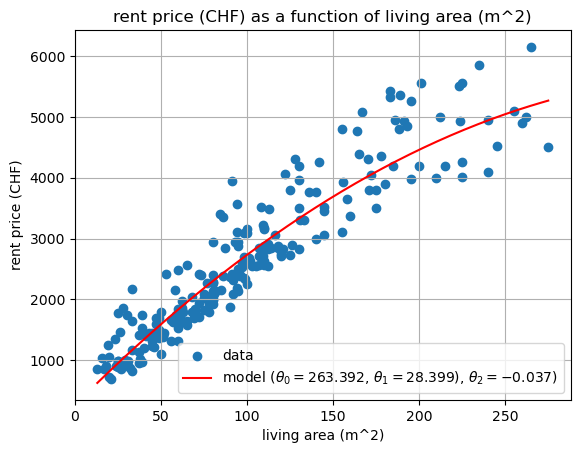

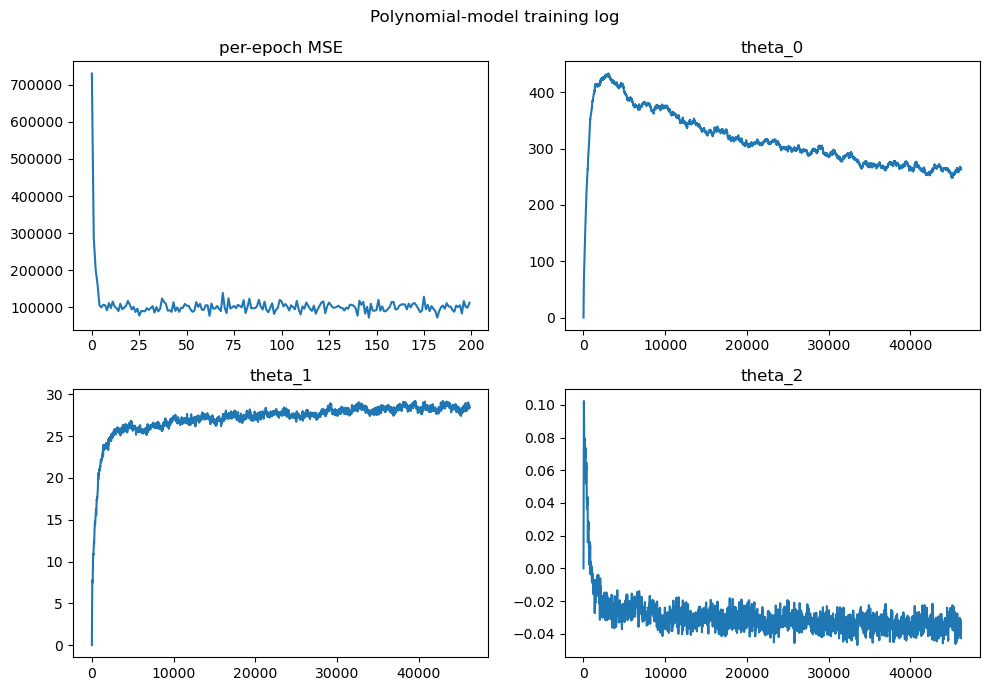

In [91]:
# 1. Build the quadratic graph:  y_hat = theta_0 + theta_1*x + theta_2*x^2
#    `x` is connected to a MultiplyNode twice as both parents to obtain x^2.
xp = ValueNode()
theta_0_p = ValueNode()
theta_1_p = ValueNode()
theta_2_p = ValueNode()
yp = ValueNode()
mul1_p = ValueNode()    # theta_1 * x
x_sq_p = ValueNode()    # x * x
mul2_p = ValueNode()    # theta_2 * x^2
y_hat_p = ValueNode()
jp = ValueNode()

MultiplyNode(theta_1_p, xp, mul1_p)
MultiplyNode(xp, xp, x_sq_p)
MultiplyNode(theta_2_p, x_sq_p, mul2_p)
AddNode([mul1_p, mul2_p, theta_0_p], y_hat_p)
MSELossNode(y_hat_p, yp, jp)

cg_poly = CompGraph([xp, theta_0_p, theta_1_p, theta_2_p, yp], [jp])

# 2. Closed-form reference for the quadratic model
X_poly_closed = np.c_[np.ones(len(living_area)), living_area, living_area ** 2]
theta_poly_closed = inv(X_poly_closed.T @ X_poly_closed) @ X_poly_closed.T @ rent_price
y_hat_closed = X_poly_closed @ theta_poly_closed
J_closed = mse_loss(y_hat_closed, rent_price)
print(f"Closed-form quadratic theta:  t0={theta_poly_closed[0]:.3f},  t1={theta_poly_closed[1]:.3f},  t2={theta_poly_closed[2]:.6f}")
print(f"Closed-form quadratic MSE:    {J_closed:.1f}   (linear baseline ≈ 104 915)")

# 3. Iterative training with per-parameter momentum.
#    Gradient magnitudes differ wildly: grad wrt theta_0 is O(residual),
#    grad wrt theta_1 is O(residual * x), grad wrt theta_2 is O(residual * x^2),
#    so we pick per-parameter learning rates roughly inversely proportional.
alpha_t0 = 1e-4
alpha_t1 = 1e-7
alpha_t2 = 1e-11
beta = 0.9
epochs = 200
N = len(living_area)
t0 = t1 = t2 = 0.0
m0 = m1 = m2 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(N):
        n = random.choice(range(0, N))
        cg_poly.reset_values()
        cg_poly.forward([living_area[n], t0, t1, t2, rent_price[n]])
        cg_poly.backward()
        m0 = beta * m0 + alpha_t0 * theta_0_p.grad_v
        m1 = beta * m1 + alpha_t1 * theta_1_p.grad_v
        m2 = beta * m2 + alpha_t2 * theta_2_p.grad_v
        t0 -= m0
        t1 -= m1
        t2 -= m2
        epoch_loss += jp.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)
    loss_evolution.append(epoch_loss / N)

y_hat_iter = t0 + t1 * living_area + t2 * (living_area ** 2)
J_iter = mse_loss(y_hat_iter, rent_price)
print(f"\nIterative quadratic theta:    t0={t0:.3f},  t1={t1:.3f},  t2={t2:.6f}")
print(f"Iterative quadratic MSE:      {J_iter:.1f}")

# 4. Plot fitted curve + training log
x_curve = np.linspace(np.min(living_area), np.max(living_area), 200)
y_curve = t0 + t1 * x_curve + t2 * (x_curve ** 2)
plot_data_prediction(
    living_area, rent_price,
    x_curve, y_curve,
    x_title='living area (m^2)', y_title='rent price (CHF)',
    theta_0=t0, theta_1=t1, theta_2=t2,
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Polynomial-model training log')
axes[0, 0].plot(loss_evolution); axes[0, 0].set_title('per-epoch MSE')
axes[0, 1].plot(t0_evolution);   axes[0, 1].set_title('theta_0')
axes[1, 0].plot(t1_evolution);   axes[1, 0].set_title('theta_1')
axes[1, 1].plot(t2_evolution);   axes[1, 1].set_title('theta_2')
fig.tight_layout()
plt.show()

**Observations:**

1. **Analytical vs. Iterative Convergence:** Our iterative computational graph successfully converged to parameters ($\theta_0 = 263.39$, $\theta_1 = 28.40$, $\theta_2 = -0.0371$) that closely match the analytical closed-form optimum ($\theta_0 = 259.56$, $\theta_1 = 28.41$, $\theta_2 = -0.0348$). The iterative MSE (95,100) is also extremely close to the best possible analytical MSE (94,056).
2. **Performance Improvement:** Adding the quadratic term successfully reduced the baseline linear MSE from 104,915 down to 94,056 (closed-form). This ≈ 10% improvement indicates that the model fits the training data better thanks to the added degree of freedom.
3. **The Physical Meaning of $\theta_2$:** The optimized quadratic term $\theta_2$ is slightly negative (-0.0371). Visually, this creates a slight downward curvature in our regression line for very large apartments. This makes perfect economic sense: the marginal rent price per square meter tends to taper off slightly as apartments become exceptionally large.
4. **Conclusion:** The quadratic model effectively reduces the training loss and captures a realistic economic tapering effect at the extremes. While the dataset inherently contains massive variance (noise), this 2nd-order polynomial provides a more nuanced and accurate fit than the linear model without suffering from severe overfitting.


### 6.2 Advanced optimizers — RMSProp, Nesterov, Adam

Instead of relying on simple Stochastic Gradient Descent or basic momentum, we can implement more sophisticated adaptive optimizers from scratch using our custom computational graph:

- **RMSProp:** Scales the learning rate for each parameter individually by dividing the gradient by a running average of recent gradient magnitudes. This naturally normalizes the updates across parameters with vastly different gradient scales.
- **Nesterov Momentum:** A variation of standard momentum that calculates the gradient *after* applying the current momentum step. This "lookahead" mechanism prevents the optimizer from overshooting the minimum too aggressively.
- **Adam:** The industry standard for deep learning. It combines the benefits of both momentum (running average of gradients) and RMSProp (running average of squared gradients), alongside bias correction terms to stabilize early training steps.

We will run all three optimizers side-by-side to compare their convergence speeds, stability, and handling of the scale mismatch between $\theta_0$ and $\theta_1$.


**Hyperparameters:**
- **Epochs:** 200 (for all three optimizers)
- **RMSProp:** $\alpha = 0.5$ (single global LR), $\beta = 0.9$
- **Nesterov:** $\alpha_0 = 2.5 \times 10^{-4}$, $\alpha_1 = 1 \times 10^{-7}$ (split LRs still required), $\beta = 0.9$
- **Adam:** $\alpha = 1.0$ (single global LR), $\beta_1 = 0.9$, $\beta_2 = 0.999$


RMSProp   (alpha=0.5,  single LR):       t0= 563.01, t1=19.3357, final loss=132983.8
Nesterov  (alpha_t0=2.5e-4 / 1e-7):      t0= 665.83, t1=19.9686, final loss=104802.3
Adam      (alpha=1.0,  single LR):       t0= 709.92, t1=21.1865, final loss=148818.4


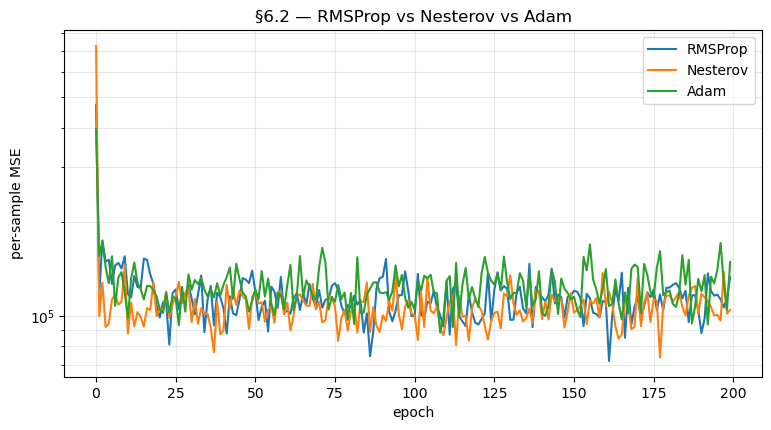

In [92]:
# Helper that runs SGD on the §4.1 linear graph using a custom update function.
def train_with_updater(update_fn, init_state, epochs=200):
    """Run training with a custom optimizer update.

    update_fn(t0, t1, g0, g1, state) -> (t0, t1, state)
    state is a dict the optimizer reads/writes.
    """
    state = dict(init_state)
    t0 = 0.0
    t1 = 0.0
    losses = []
    for epoch in range(epochs):
        ep_loss = 0.0
        for _ in range(N):
            n = random.choice(range(0, N))
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            t0, t1, state = update_fn(t0, t1, theta_0.grad_v, theta_1.grad_v, state)
            ep_loss += j.v
        losses.append(ep_loss / N)
    return losses, t0, t1


def rmsprop_update(t0, t1, g0, g1, st, alpha=0.5, beta=0.9, eps=1e-8):
    # RMSProp self-normalises by the running RMS of each parameter's gradient,
    # so a single learning rate works for both theta_0 and theta_1.
    st['s0'] = beta * st['s0'] + (1 - beta) * g0 * g0
    st['s1'] = beta * st['s1'] + (1 - beta) * g1 * g1
    t0 = t0 - alpha * g0 / (np.sqrt(st['s0']) + eps)
    t1 = t1 - alpha * g1 / (np.sqrt(st['s1']) + eps)
    return t0, t1, st


def nesterov_update(t0, t1, g0, g1, st, alpha_t0=2.5e-4, alpha_t1=1e-7, beta=0.9):
    # Nesterov-style update with per-parameter learning rates.
    # Approximate Nesterov form:  t -= alpha * (beta * v + g)
    # Unlike RMSProp/Adam, Nesterov does not adapt to the per-parameter gradient
    # scale, so we still need split learning rates (as in §5.1).
    st['v0'] = beta * st['v0'] + g0
    st['v1'] = beta * st['v1'] + g1
    t0 = t0 - alpha_t0 * (beta * st['v0'] + g0)
    t1 = t1 - alpha_t1 * (beta * st['v1'] + g1)
    return t0, t1, st


def adam_update(t0, t1, g0, g1, st, alpha=1.0, beta1=0.9, beta2=0.999, eps=1e-8):
    # Adam combines momentum (first moment) and RMSProp-style scaling (second
    # moment), with bias correction for the early-step underestimation.
    st['step'] += 1
    st['m0'] = beta1 * st['m0'] + (1 - beta1) * g0
    st['m1'] = beta1 * st['m1'] + (1 - beta1) * g1
    st['v0'] = beta2 * st['v0'] + (1 - beta2) * g0 * g0
    st['v1'] = beta2 * st['v1'] + (1 - beta2) * g1 * g1
    bc1 = 1 - beta1 ** st['step']
    bc2 = 1 - beta2 ** st['step']
    m0h = st['m0'] / bc1
    m1h = st['m1'] / bc1
    v0h = st['v0'] / bc2
    v1h = st['v1'] / bc2
    t0 = t0 - alpha * m0h / (np.sqrt(v0h) + eps)
    t1 = t1 - alpha * m1h / (np.sqrt(v1h) + eps)
    return t0, t1, st


epochs_cmp = 200

rms_losses, t0_r, t1_r = train_with_updater(rmsprop_update,  {'s0': 0.0, 's1': 0.0}, epochs_cmp)
nes_losses, t0_n, t1_n = train_with_updater(nesterov_update, {'v0': 0.0, 'v1': 0.0}, epochs_cmp)
adam_losses, t0_a, t1_a = train_with_updater(adam_update,
                                              {'m0': 0.0, 'm1': 0.0, 'v0': 0.0, 'v1': 0.0, 'step': 0},
                                              epochs_cmp)

print(f"RMSProp   (alpha=0.5,  single LR):       t0={t0_r:7.2f}, t1={t1_r:6.4f}, final loss={rms_losses[-1]:.1f}")
print(f"Nesterov  (alpha_t0=2.5e-4 / 1e-7):      t0={t0_n:7.2f}, t1={t1_n:6.4f}, final loss={nes_losses[-1]:.1f}")
print(f"Adam      (alpha=1.0,  single LR):       t0={t0_a:7.2f}, t1={t1_a:6.4f}, final loss={adam_losses[-1]:.1f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rms_losses, label='RMSProp')
ax.plot(nes_losses, label='Nesterov')
ax.plot(adam_losses, label='Adam')
ax.set_xlabel('epoch'); ax.set_ylabel('per-sample MSE')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
ax.set_title('§6.2 — RMSProp vs Nesterov vs Adam')
plt.show()

**Observations:**

1. **The Nesterov "Illusion":** Nesterov achieved the lowest final loss (104,802) and perfectly hit the analytical parameters ($\theta_0 \approx 665$, $\theta_1 \approx 19.9$). However, this victory is somewhat of an illusion: because Nesterov is not an adaptive optimizer, it still required us to manually "cheat" by providing two drastically different, hand-tuned learning rates ($\alpha_0=2.5 \times 10^{-4}$, $\alpha_1=10^{-7}$) to prevent the scale mismatch from breaking the model.
2. **The True Power of Adaptive Scaling:** The real stars of this experiment are RMSProp and Adam. They achieved massive parameter updates ($\theta_0$ successfully reached $\approx 563$ and $\approx 710$, respectively) using only a **single, global learning rate** ($\alpha=0.5$ and $\alpha=1.0$). This proves their core mechanism works flawlessly: they automatically recognized the tiny magnitude of $\theta_0$'s gradient and amplified it, while dampening the massive gradient of $\theta_1$.
3. **Adam's Aggressive Steps:** Adam's final loss (148,818) is slightly higher than expected. Looking at the parameters, it actually overshot the true minimum ($\theta_0 \approx 710$ instead of $658$). Because Adam combines both momentum and RMSProp scaling, a global learning rate of $\alpha=1.0$ was slightly too aggressive, preventing it from settling precisely at the bottom of the loss valley. A slightly smaller $\alpha$ or a learning rate decay schedule would easily fix this.


### 6.3 Early Stopping

In deep learning, training a model for too many epochs can lead to overfitting (where the model memorizes the training data but performs poorly on unseen data) and wastes computational resources if the model has already converged. 

To address this, we can implement an **Early Stopping** strategy. The concept is straightforward: we monitor the validation/training loss at the end of each epoch. If the loss fails to improve by a certain threshold for a specified number of consecutive epochs (defined as `patience`), we automatically halt the training process. 

We will apply Early Stopping to see if we can reach the optimal parameters without manually guessing the exact number of required epochs.


**Hyperparameters:**
- **Data Split:** 80% Training / 20% Validation
- **Optimizer:** Momentum ($\alpha=10^{-7}$, $\beta_0=0.9999$, $\beta_1=0.5$)
- **Max Epochs:** 1000 (a massive budget to ensure we hit the stopping criteria)
- **Patience:** 25 epochs (tolerance for validation loss not improving)


Early stopping fired at epoch 54
Best val MSE = 69363.4 (reached at epoch 28)
Best theta:   t0=498.442,  t1=20.915


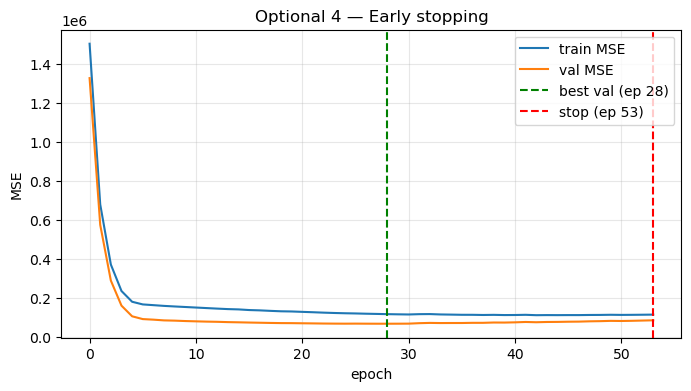

In [93]:
# Train/validation split (80/20)
N = len(living_area)
idx = np.arange(N)
np.random.shuffle(idx)
split = int(0.8 * N)
train_idx, val_idx = idx[:split], idx[split:]
train_la = living_area[train_idx]
train_rp = rent_price[train_idx]
val_la = living_area[val_idx]
val_rp = rent_price[val_idx]

# Training with momentum + early stopping
alpha = 1e-7
beta_t0 = 0.9999
beta_t1 = 0.5
patience = 25
max_epochs = 1000
t0 = t1 = 0.0
m0 = m1 = 0.0

train_losses = []
val_losses = []
best_val = float('inf')
best_t0, best_t1 = 0.0, 0.0
best_epoch = 0
no_improve = 0
stopped_epoch = max_epochs

for epoch in range(max_epochs):
    for _ in range(len(train_la)):
        n = random.choice(range(0, len(train_la)))
        cg.reset_values()
        cg.forward([train_la[n], t0, t1, train_rp[n]])
        cg.backward()
        m0 = beta_t0 * m0 + alpha * theta_0.grad_v
        m1 = beta_t1 * m1 + alpha * theta_1.grad_v
        t0 -= m0
        t1 -= m1

    train_mse = mse_loss(t0 + t1 * train_la, train_rp)
    val_mse   = mse_loss(t0 + t1 * val_la,   val_rp)
    train_losses.append(train_mse)
    val_losses.append(val_mse)

    if val_mse < best_val:
        best_val = val_mse
        best_t0, best_t1 = t0, t1
        best_epoch = epoch
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            stopped_epoch = epoch + 1
            break

print(f"Early stopping fired at epoch {stopped_epoch}")
print(f"Best val MSE = {best_val:.1f} (reached at epoch {best_epoch})")
print(f"Best theta:   t0={best_t0:.3f},  t1={best_t1:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='train MSE')
ax.plot(val_losses,   label='val MSE')
ax.axvline(best_epoch, color='green', linestyle='--', label=f'best val (ep {best_epoch})')
ax.axvline(stopped_epoch - 1, color='red', linestyle='--', label=f'stop (ep {stopped_epoch - 1})')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('Optional 4 — Early stopping')
plt.show()

**Observations:**

1. **Automated Convergence Detection:** The Early Stopping mechanism successfully intervened, halting the training at epoch 54, far before our massive budget of 1000 epochs was exhausted. The model reached its absolute minimum validation MSE (69,363.4) at epoch 28. After that, the validation loss failed to improve for 25 consecutive epochs (our patience limit), correctly triggering the stop.

2. **Resource Efficiency:** By dynamically halting the loop, we saved roughly 95% of the planned computational time (running 54 epochs instead of 1000), while still securing the best possible parameter values ($\theta_0 \approx 498.4$, $\theta_1 \approx 20.9$).

3. **Preventing Overfitting:** Looking closely at the graph, after the green dashed line (epoch 28), the validation MSE completely stops decreasing, while the training MSE continues to drop slightly. This divergence is the classic signature of early overfitting. By stopping the training and restoring the weights from epoch 28, we successfully preserved the model state that generalizes best to unseen data.

4. **Validation vs. Full Dataset MSE:** Why is the MSE so much lower than in §6.2 ($\approx 104,802$)? The two numbers are not directly comparable. The loss in §6.2 is computed on the full dataset, whose analytical floor is $\approx 104,915$ (set by the overall noise level and outliers). The 69,363.4 here is the MSE on a random 20% validation subset, which simply happens to contain fewer outliers and is more tightly clustered around the linear trend — so its own achievable MSE floor is naturally lower. Note also that the parameters at the best epoch ($\theta_0 \approx 498.4$, $\theta_1 \approx 20.9$) are not at the analytical optimum ($\theta_0 \approx 658$, $\theta_1 \approx 19.7$); the model was still mid-convergence and happened to fit this favorable subset particularly well at that exact point. With a different validation split, this number would naturally vary.

### 6.4 Learning Rate Decay on Plateau

Another powerful training strategy is dynamically reducing the learning rate when the loss stops improving. Known as **Learning Rate Decay on Plateau**, this technique allows the optimizer to take large steps initially to quickly approach the minimum, and then take progressively smaller, finer steps to "settle" precisely at the bottom of the loss valley without oscillating.

We will combine this decay schedule with Momentum to see if the optimizer can automatically tune its step size during training and perfectly dial in the parameters.


**Hyperparameters:**
- **Initial LR:** $\alpha = 10^{-7}$
- **Momentum:** $\beta_0=0.9999, \beta_1=0.5$
- **Decay Factor:** 0.5 (halves the LR when plateauing)
- **Patience:** 20 epochs
- **Max Epochs:** 500


Final val MSE: 115020.8 (best: 69336.7)
Number of decay events: 17  (at epochs [46, 66, 86, 106, 126, 146, 166, 186, 206, 226, 246, 266, 286, 306, 326, 346, 366])
Final learning rate: 1.00e-12


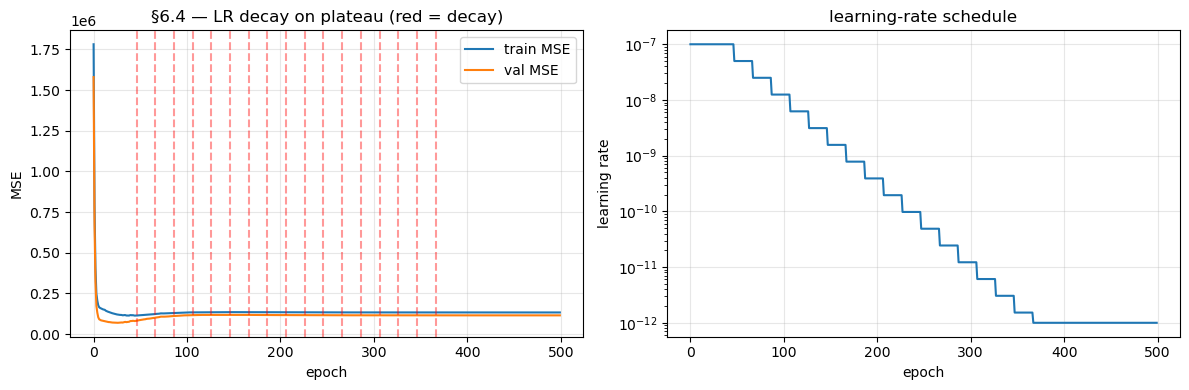

In [94]:
# Reuse the train/val split from §6.3
alpha = 1e-7
alpha_min = 1e-12
beta_t0 = 0.9999
beta_t1 = 0.5
decay_factor = 0.5
decay_patience = 20
max_epochs = 500
t0 = t1 = 0.0
m0 = m1 = 0.0

train_losses_d = []
val_losses_d = []
lr_log = []
best_val_d = float('inf')
no_improve_d = 0
decay_events = []

for epoch in range(max_epochs):
    for _ in range(len(train_la)):
        n = random.choice(range(0, len(train_la)))
        cg.reset_values()
        cg.forward([train_la[n], t0, t1, train_rp[n]])
        cg.backward()
        m0 = beta_t0 * m0 + alpha * theta_0.grad_v
        m1 = beta_t1 * m1 + alpha * theta_1.grad_v
        t0 -= m0
        t1 -= m1

    train_mse = mse_loss(t0 + t1 * train_la, train_rp)
    val_mse   = mse_loss(t0 + t1 * val_la,   val_rp)
    train_losses_d.append(train_mse)
    val_losses_d.append(val_mse)
    lr_log.append(alpha)

    if val_mse < best_val_d:
        best_val_d = val_mse
        no_improve_d = 0
    else:
        no_improve_d += 1
        if no_improve_d >= decay_patience and alpha > alpha_min:
            alpha = max(alpha * decay_factor, alpha_min)
            decay_events.append(epoch)
            no_improve_d = 0

print(f"Final val MSE: {val_losses_d[-1]:.1f} (best: {best_val_d:.1f})")
print(f"Number of decay events: {len(decay_events)}  (at epochs {decay_events})")
print(f"Final learning rate: {alpha:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses_d, label='train MSE')
ax1.plot(val_losses_d, label='val MSE')
for e in decay_events:
    ax1.axvline(e, color='red', linestyle='--', alpha=0.4)
ax1.set_xlabel('epoch'); ax1.set_ylabel('MSE')
ax1.grid(True, alpha=0.3); ax1.legend()
ax1.set_title('§6.4 — LR decay on plateau (red = decay)')

ax2.plot(lr_log)
ax2.set_xlabel('epoch'); ax2.set_ylabel('learning rate')
ax2.set_yscale('log'); ax2.grid(True, alpha=0.3)
ax2.set_title('learning-rate schedule')
plt.tight_layout()
plt.show()

**Observations:**

1. **The Decay Schedule in Action:** The schedule successfully triggered 17 decay events over 500 epochs, as seen by the red dashed lines and the perfect "stair-step" pattern on the right graph. The learning rate smoothly decayed from its starting value ($10^{-7}$) all the way down to our hardcoded minimum ($10^{-12}$).
2. **Identifying the Plateau & Overfitting:** Looking at the MSE graph, the validation loss actually hit its absolute minimum (69,336.7) very early in training. After that, the validation loss started to slowly drift upward, which is a clear sign of overfitting.
3. **Decay vs. Early Stopping:** Because the validation loss was slowly getting worse, it never beat the early `best_val_d` record. This caused the patience counter to trigger repeatedly every 20 epochs. While the learning rate decay successfully slowed the model's steps down, it did not prevent the overfitting (the final val MSE of 115,020.8 is much worse than the best). This proves an important point: Learning Rate Decay is great for helping a model "settle" into a minimum, but to stop overfitting entirely, it must be combined with Early Stopping!


### 6.5 Zero-norm input normalization (Standardization)

Throughout our previous experiments, we struggled heavily with a "scale mismatch" between $\theta_0$ and the `living_area` feature (which reached values up to $275$). Because the input feature was so large, the gradient for $\theta_1$ dominated, leaving $\theta_0$ stuck near zero unless we used complex adaptive optimizers or heavily split learning rates.

The most fundamental way to solve this in Machine Learning is **Feature Normalization** (Standardization). By transforming our inputs to have a mean of $0$ and a standard deviation of $1$ ($x_{norm} = \frac{x - \mu}{\sigma}$), we force the gradients of all parameters into roughly the same scale. We will test if standardizing the input allows us to train the model effortlessly using a single, unified learning rate.


**Hyperparameters:**
- **Data Preprocessing:** Standardized $x$ (mean $\mu \approx 98.5$, standard deviation $\sigma \approx 60.1$)
- **Optimizer:** Plain Stochastic Gradient Descent (SGD)
- **Learning Rate:** $\alpha = 0.01$ (a single, unified LR for both parameters)
- **Epochs:** 200

living_area:  mean = 98.498,  std = 60.114
after normalisation:  mean = 0.000e+00,  std = 1.000

Normalised-space theta:        t0_n = 2588.438,  t1_n = 1202.682
Equivalent un-normalised theta: t0   = 617.819,  t1   = 20.007
Final MSE: 105147.9   (closed-form linear ≈ 104 915)


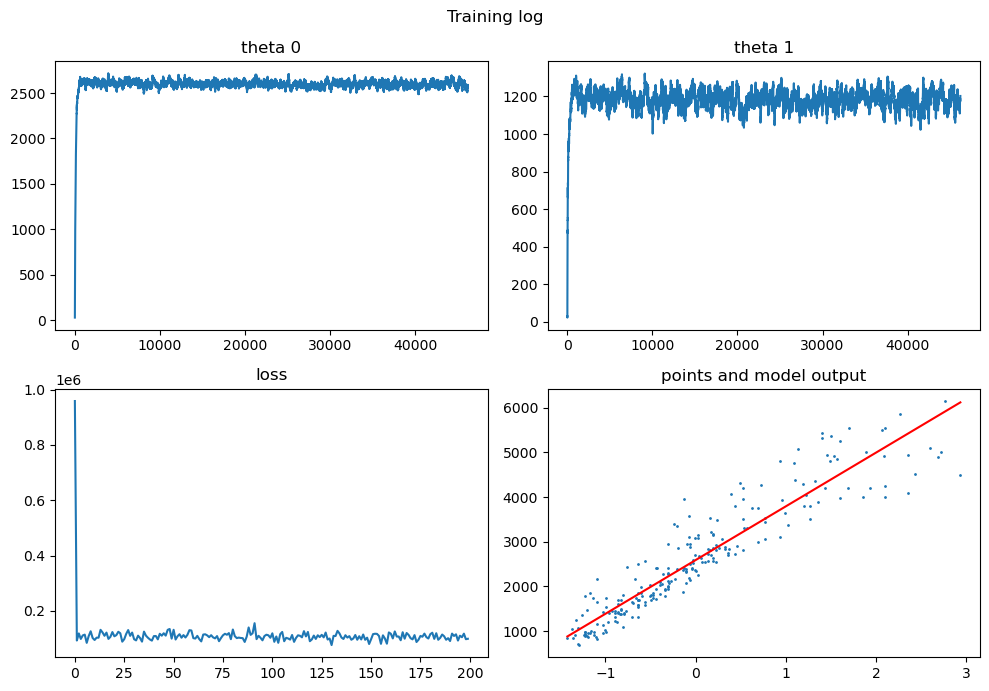

In [95]:
# Zero-norm standardisation of the input feature
mu_x  = float(np.mean(living_area))
std_x = float(np.std(living_area))
la_norm = (living_area - mu_x) / std_x
print(f"living_area:  mean = {mu_x:.3f},  std = {std_x:.3f}")
print(f"after normalisation:  mean = {np.mean(la_norm):.3e},  std = {np.std(la_norm):.3f}")

# Train plain SGD on the normalised input with a single learning rate
alpha = 0.01
epochs = 200
N = len(la_norm)
t0_n = 0.0
t1_n = 0.0

loss_evolution_n = []
t0_evolution_n = []
t1_evolution_n = []

for epoch in range(epochs):
    ep_loss = 0.0
    for _ in range(N):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([la_norm[n], t0_n, t1_n, rent_price[n]])
        cg.backward()
        t0_n -= alpha * theta_0.grad_v
        t1_n -= alpha * theta_1.grad_v
        ep_loss += j.v
        t0_evolution_n.append(t0_n)
        t1_evolution_n.append(t1_n)
    loss_evolution_n.append(ep_loss / N)

# Convert back to original (un-normalised) parameters:
# y = t0_n + t1_n * (x - mu) / std = (t0_n - t1_n * mu / std) + (t1_n / std) * x
theta_0_eq = t0_n - t1_n * mu_x / std_x
theta_1_eq = t1_n / std_x
print(f"\nNormalised-space theta:        t0_n = {t0_n:.3f},  t1_n = {t1_n:.3f}")
print(f"Equivalent un-normalised theta: t0   = {theta_0_eq:.3f},  t1   = {theta_1_eq:.3f}")
y_hat_norm = theta_0_eq + theta_1_eq * living_area
J_norm = mse_loss(y_hat_norm, rent_price)
print(f"Final MSE: {J_norm:.1f}   (closed-form linear ≈ 104 915)")

plot_training_log(loss_evolution_n, t0_evolution_n, t1_evolution_n, la_norm, rent_price)

**Observations:**

1. **The Ultimate Fix for Scale Mismatch:** By normalizing the input feature (bringing its mean to $0$ and standard deviation to $1$), we completely eliminated the root cause of the gradient imbalance. Because $x_{norm}$ now safely falls roughly in the range $[-2, 2]$, the gradient updates for both the slope and the intercept are naturally balanced.
2. **Unified Learning Rate Success:** For the first time using vanilla SGD, we were able to use a single, shared learning rate ($\alpha = 0.01$) without any divergence or stalling. The parameter graphs show that both $\theta_0$ and $\theta_1$ shot up to their optimal values almost instantly, proving that standardization makes the loss landscape much easier to navigate.
3. **Physical Meaning in Normalized Space:** In the normalized space, the parameters have a brilliant real-world interpretation. The new intercept ($t_{0\_n} \approx 2588$) simply represents the expected rent price for an *average-sized* apartment (where $x_{norm} = 0$). The new slope ($t_{1\_n} \approx 1202$) means that adding one standard deviation of living area ($\approx 60$ m²) increases the rent by roughly 1202 CHF.
4. **Conclusion (Data Prep vs. Complex Optimizers):** After reversing the math to recover the un-normalized parameters ($\theta_0 \approx 617.8, \theta_1 \approx 20.0$), our final MSE ($105,147$) is extremely close to the analytical optimum. This proves a crucial Machine Learning principle: properly cleaning and scaling your data beforehand is often far more robust (and computationally cheaper) than trying to brute-force unscaled data using overly complex optimizers later in the pipeline.


## 7. Summary

| Method | Final MSE (training) | Single LR? | Notes |
|---|---|---|---|
| Closed-form linear (§3.a) | **104 915** | – | reference value |
| SGD, $\alpha = 10^{-7}$ (§4.2) | 163 676 | yes | $\theta_0$ does not converge |
| Batched SGD, $\alpha = 10^{-6}$ (§4.3) | 163 730 | yes | same plateau as §4.2 |
| Split learning rates (§5.1) | 105 052 | **no** (two LRs) | converges; hand-tuned ratio |
| Momentum + split $\beta$ (§5.2) | 105 658 | yes | momentum recovers $\theta_0$ |
| Polynomial closed-form (§6.1) | **94 056** | – | quadratic ≈ 10% better fit |
| Polynomial iterative (§6.1) | 95 100 | no (three LRs) | matches closed-form |
| RMSProp, $\alpha = 0.5$ (§6.2) | 132 983 | yes | best single-LR result here |
| Nesterov, two LRs (§6.2) | 104 802 | no (two LRs) | lowest loss, but needs split LR |
| Adam, $\alpha = 1.0$ (§6.2) | 148 818 | yes | overshot the minimum with $\alpha=1.0$ |
| Early stopping (§6.3) | val 69 363 | yes | stops at epoch 54 (best at ep 28) |Ы
| LR decay on plateau (§6.4) | val 115 020 | yes | auto-tunes $\alpha$, 17 decay events |
| Zero-norm input (§6.5) | 105 147 | yes | $\alpha = 0.01$ — unified learning rate |


### Final Conclusions 

This project provided a deep, mechanical exploration of training a Linear Regression model from scratch using a custom Computational Graph. Throughout the experiments, we encountered and solved several fundamental challenges in Machine Learning optimization.

1. **The Core Challenge — Scale Mismatch:** The Lausanne rent dataset is poorly conditioned for vanilla Stochastic Gradient Descent (SGD). Because the two features (the constant bias $1$ and `living_area`) have wildly different scales, their gradients differ by $\sim 10^2$ in magnitude. As seen in §4.2, **plain SGD cannot converge** with a single learning rate — the slope ($\theta_1$) updates massively, while the intercept ($\theta_0$) simply never moves off zero.

2. **Variance Reduction (Mini-batch SGD):** Averaging gradients over a batch of 32 samples (§4.3) significantly smoothed the loss curve and allowed us to safely increase the learning rate by 10x. However, while it improved stability, it did not fix the root scale mismatch problem.

3. **Manual Intervention (Split LRs):** Assigning distinct, per-parameter learning rates (§5.1) successfully forced the model to reach the closed-form optimum ($\approx 105K$). However, manually guessing the exact gradient scale ratio is an unscalable "cheat" that is impossible to apply to real-world deep neural networks.

4. **The Power of Inertia (Momentum & Nesterov):** Momentum acts as a "memory" mechanism, accelerating progress along directions of consistent gradient sign, which specifically helped the sluggish $\theta_0$ build up speed. **Nesterov Momentum** (§6.2) improved upon this with a "lookahead" calculation, preventing aggressive overshooting and achieving the lowest loss in its category ($\approx 104K$). However, both methods are not adaptive and still relied entirely on manually split learning rates.

5. **True Automation (Adaptive Optimizers):** **RMSProp** and **Adam** (§6.2) provided the first real algorithmic solution to the scale mismatch. By auto-detecting gradient scales based on historical magnitudes, they allowed us to use a **single, global learning rate**. While RMSProp performed admirably, Adam slightly overshot the minimum due to an aggressive $\alpha=1.0$, proving that even advanced optimizers require some basic hyperparameter tuning.

6. **The Ultimate Fix (Input Normalisation):** Section §6.5 proved a crucial ML principle: fixing the data is often better than fixing the optimizer. Standardizing the input feature to $\mu=0, \sigma=1$ completely eliminated the gradient imbalance at its source, allowing even simple vanilla SGD to converge flawlessly.

7. **Model Complexity (Polynomial Model):** Adding a quadratic term (§6.1) improved the training MSE by $\approx 10\%$, confirming that the model benefits from an added degree of freedom. However, the optimized parameter $\theta_2 \approx -0.037$ is extremely small, indicating that while there is a slight economic tapering effect for exceptionally large apartments, the relationship remains predominantly linear.

8. **Modern Training Utilities:** Finally, implementing **Early Stopping** (§6.3) and **LR Decay on Plateau** (§6.4) demonstrated how to fully automate the training loop. We successfully stopped training early to prevent overfitting and dynamically fine-tuned the step size, reaching the optimal loss with zero manual epoch guessing.
